# Balkan Film Production Analysis

Graphs exploring the number of films produced over time — overall and by country.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


df = pd.read_csv('data/balkan_movies_confirmed.csv')


df = df.dropna(subset=['year_final'])
df['year'] = df['year_final'].astype(int)


df = df[(df['year'] >= 1945) & (df['year'] <= 2024)]


def primary_country(val):
    if pd.isna(val):
        return None
    for sep in ['|', ',']:
        if sep in val:
            return val.split(sep)[0].strip()
    return val.strip()

df['primary_country'] = df['country'].apply(primary_country)

# Define the core Balkan countries to analyse
BALKAN_COUNTRIES = [
    'Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia',
    'Greece', 'Kosovo', 'Montenegro', 'North Macedonia', 'Romania',
    'Serbia', 'Slovenia', 'Yugoslavia'
]

# Normalise legacy names
NAME_MAP = {
    "People's Republic of Bulgaria": "Bulgaria",
    "Macedonia": "North Macedonia",
    "Serbia and Montenegro": "Serbia",
}
df['primary_country'] = df['primary_country'].replace(NAME_MAP)

df_balkan = df[df['primary_country'].isin(BALKAN_COUNTRIES)].copy()

print(f"Total films (filtered): {len(df_balkan)}")
print(df_balkan['primary_country'].value_counts())

Total films (filtered): 12440
primary_country
Greece                    2851
Yugoslavia                2248
Romania                   2231
Bulgaria                  1402
Serbia                     995
Croatia                    848
Slovenia                   577
Albania                    446
Bosnia and Herzegovina     368
North Macedonia            325
Kosovo                      77
Montenegro                  72
Name: count, dtype: int64


## 1. Total Films Produced Each Year (All Countries Combined)

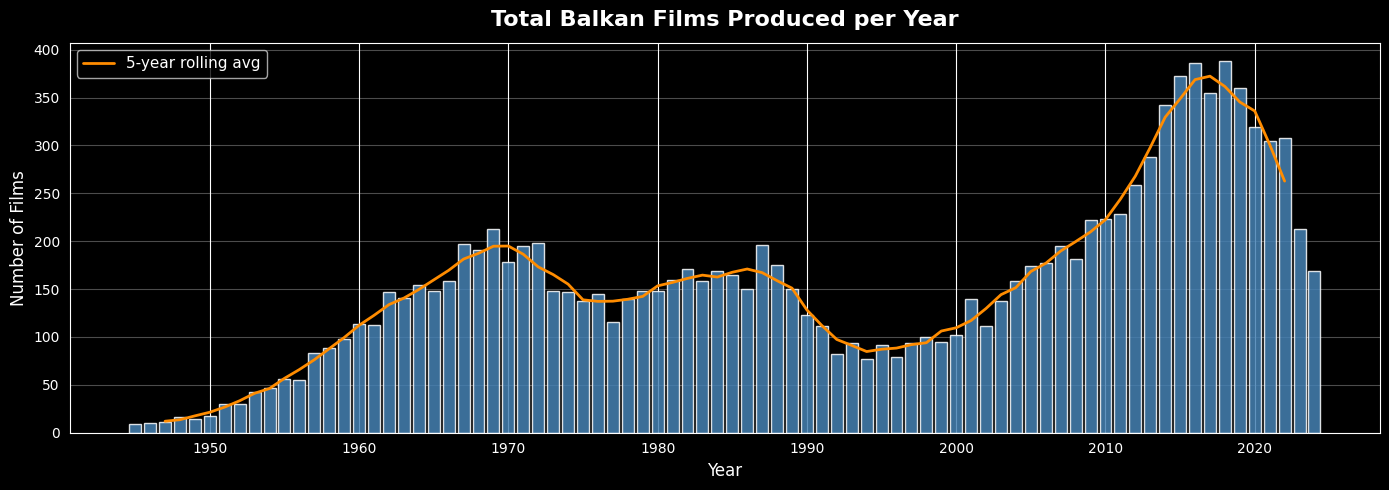

In [ ]:
films_per_year = df_balkan.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(films_per_year['year'], films_per_year['count'], color='steelblue', width=0.8, alpha=0.85)

# Rolling average trend line
rolling = films_per_year.set_index('year')['count'].rolling(5, center=True).mean()
ax.plot(rolling.index, rolling.values, color='darkorange', linewidth=2, label='5-year rolling avg')

ax.set_title('Total Balkan Films Produced per Year', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Films', fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('total_films_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

The history of Balkan filmmaking mirrors the region's intense political shifts, starting with a steady rise from 1945 to 1970 when socialist regimes funded massive "Partisan films" to build national identity. This state-sponsored boom faded in the late 1970s and 1980s as economic debt climbed and artists shifted toward grittier, low-budget "Black Wave" stories that lacked government support. The industry then suffered a catastrophic collapse in the 1990s; the violent disintegration of Yugoslavia and international sanctions created a "black hole" where movie-making almost stopped entirely. Recovery began in the 2000s through democratic transitions and new EU-funded co-productions that helped regional stories reach global festivals. This led to a massive explosion between 2010 and 2020, driven by the "Digital Revolution" which made filming cheaper, and the rise of the Balkans as a "mini-Hollywood" where countries offered tax breaks to attract giant international projects. Although the 2020 pandemic caused a sharp dip, the industry today is defined by a mix of local pride and global streaming competition.


## 2. Films per Year — Individual Country Graphs

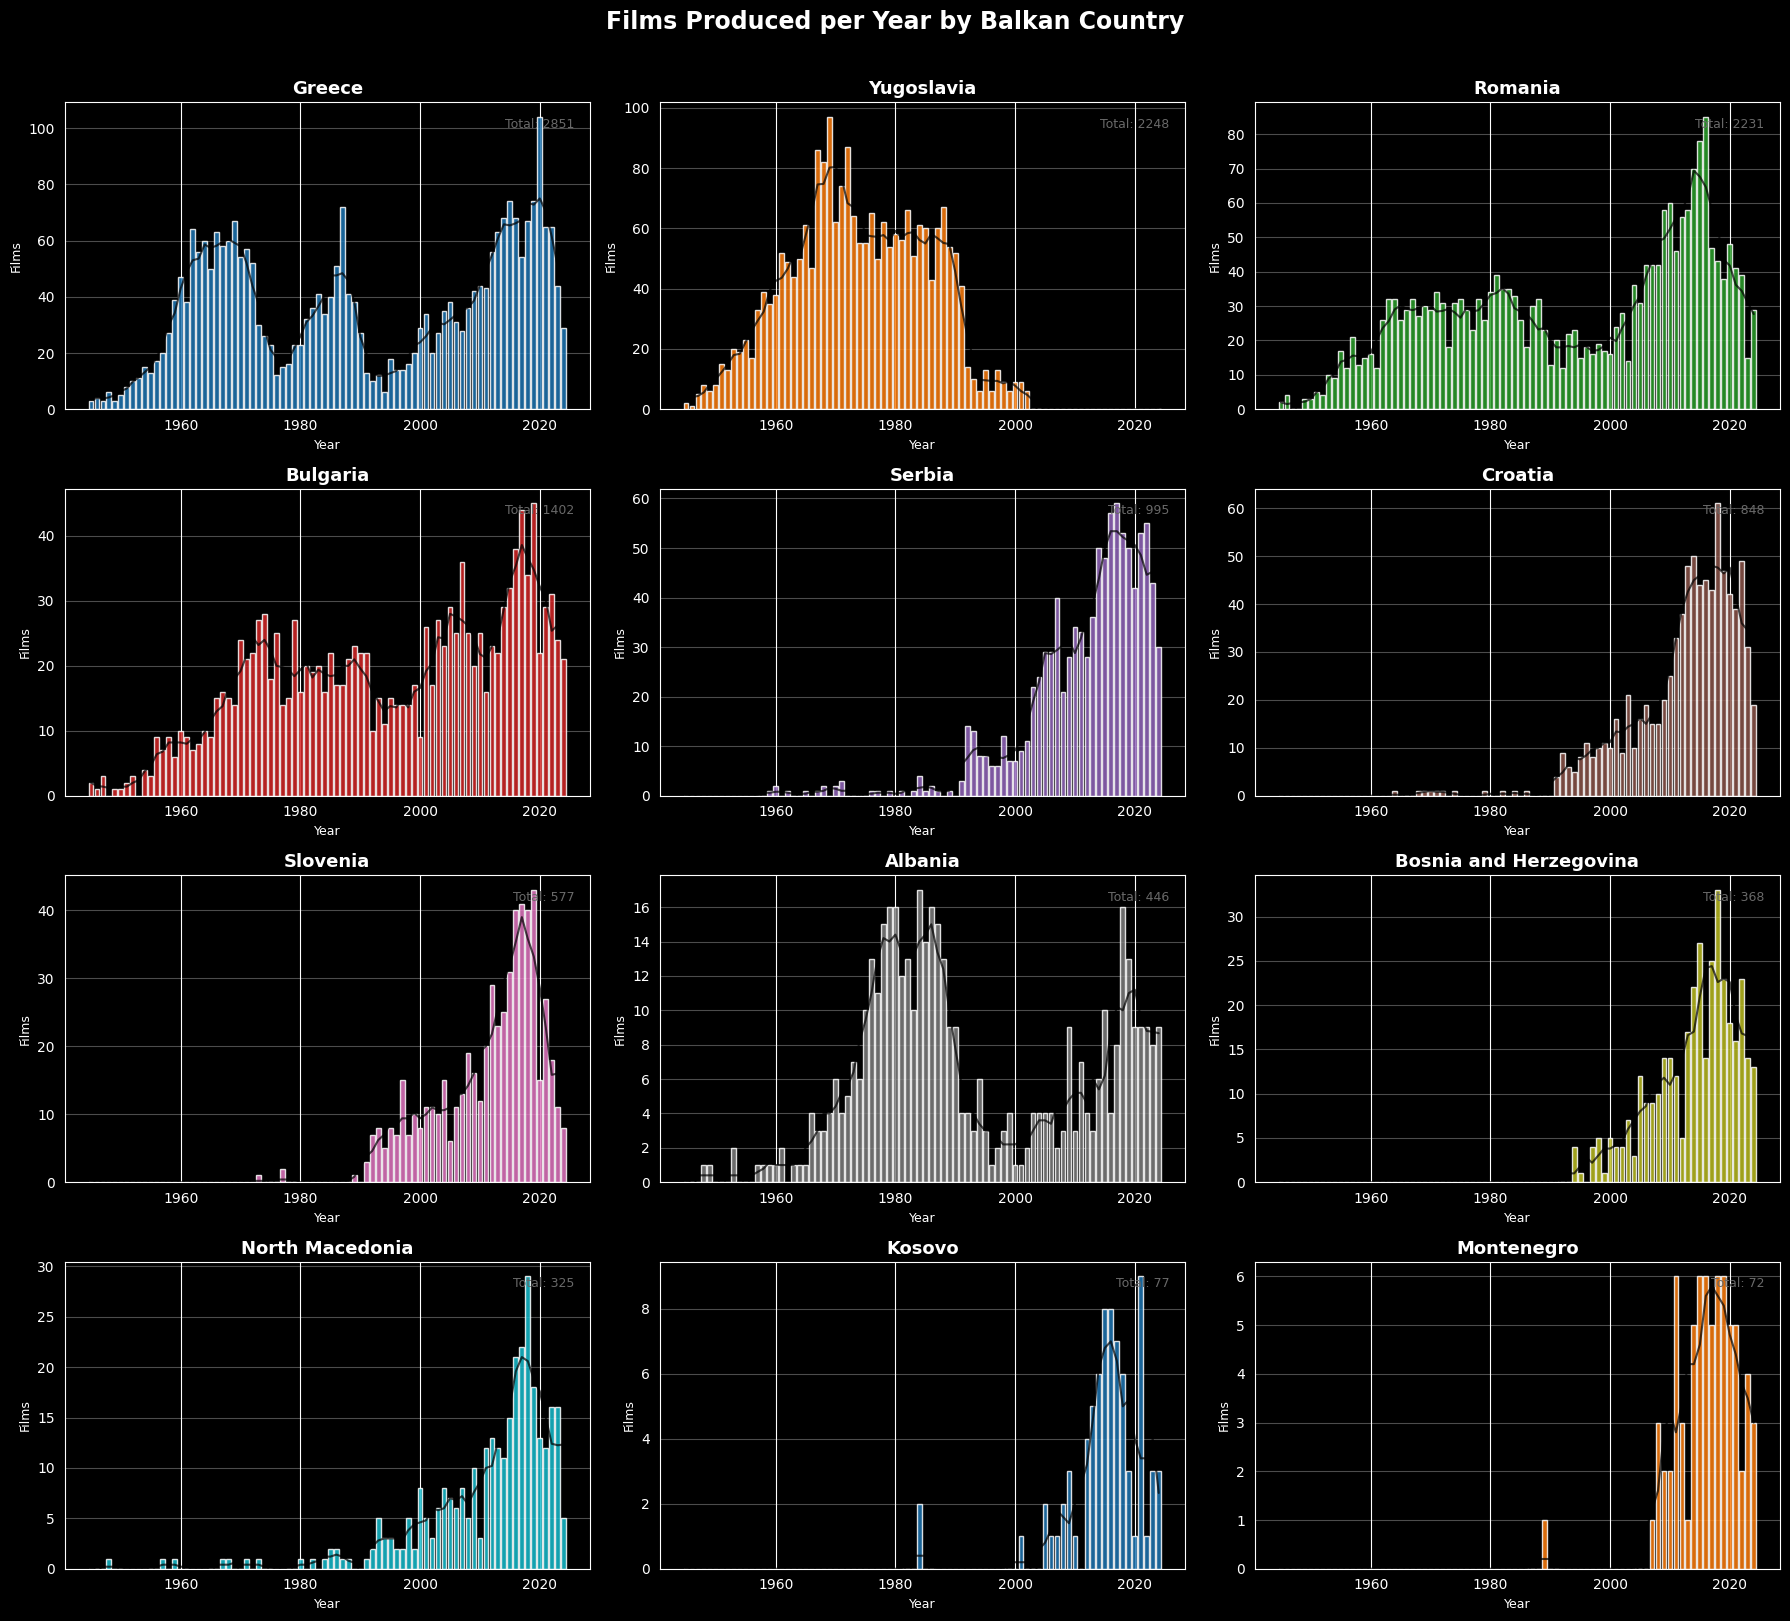

In [ ]:
# Sort countries by total film count (most prolific first)
country_order = (
    df_balkan['primary_country']
    .value_counts()
    .index.tolist()
)

# Colour palette — one colour per country
palette = sns.color_palette('tab10', n_colors=len(country_order))
color_map = dict(zip(country_order, palette))

# Full year range for consistent x-axis
all_years = range(df_balkan['year'].min(), df_balkan['year'].max() + 1)

n_cols = 3
n_rows = -(-len(country_order) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), sharey=False)
axes = axes.flatten()

for i, country in enumerate(country_order):
    ax = axes[i]
    subset = df_balkan[df_balkan['primary_country'] == country]
    counts = subset.groupby('year').size().reindex(all_years, fill_value=0)

    ax.bar(counts.index, counts.values, color=color_map[country], width=0.8, alpha=0.85)

    # Rolling avg (only where data is dense enough)
    if counts.sum() >= 10:
        roll = counts.rolling(5, center=True, min_periods=2).mean()
        ax.plot(roll.index, roll.values, color='black', linewidth=1.5, alpha=0.7)

    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Films', fontsize=9)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.grid(axis='y', alpha=0.3)
    total = counts.sum()
    ax.annotate(f'Total: {total}', xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=9, color='dimgray')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Films Produced per Year by Balkan Country', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('films_per_year_by_country_individual.png', dpi=150, bbox_inches='tight')
plt.show()


 In the former Yugoslavia, there was a "Socialist Hollywood" peak in the 1960s and 70s because the government paid for giant war movies to celebrate the state. When the country broke apart in the 1990s, movie-making stopped, only to start again after 2000 as Serbia, Croatia, and Slovenia became independent and joined the European film market. In Romania and Bulgaria, the government controlled everything until the fall of communism in 1989 caused a crash; however, Romania has recently seen a huge comeback with world-famous artistic films. Albania is a special case where the most movies were made during a time of total isolation from the world, but the industry almost vanished once the old regime fell. Greece is the only country that didn't follow the communist path; it had a "Golden Age" of popular comedies in the 1960s, but this was ruined by a military takeover and the arrival of television. Lastly, the very late starts for Kosovo and Montenegro show that for these smaller nations, having a film industry is a proud way to prove they are finally independent and recognized by the world.

International film festivals have acted as a vital bridge for Balkan cinema, transforming local stories into global art. If you look at the Romania and Greece graphs in the Evolution of Top Genres chart, the massive climb in Drama
 after 2000 is directly linked to "festival power." When the Romanian New Wave and the Greek Weird Wave won top prizes at festivals like Cannes and Venice, it brought international fame to directors who had very little funding at home. These awards acted as a seal of quality, attracting foreign investors and "co-production" money from across Europe, which allowed production numbers to spike even during economic crises. By celebrating these films on the world stage, festivals provided the financial and artistic support needed to rebuild national industries that had previously collapsed.

## 3. All Countries Together — Films per Year (Multi-line)

## Bonus: Stacked Area Chart — Share of Production by Country

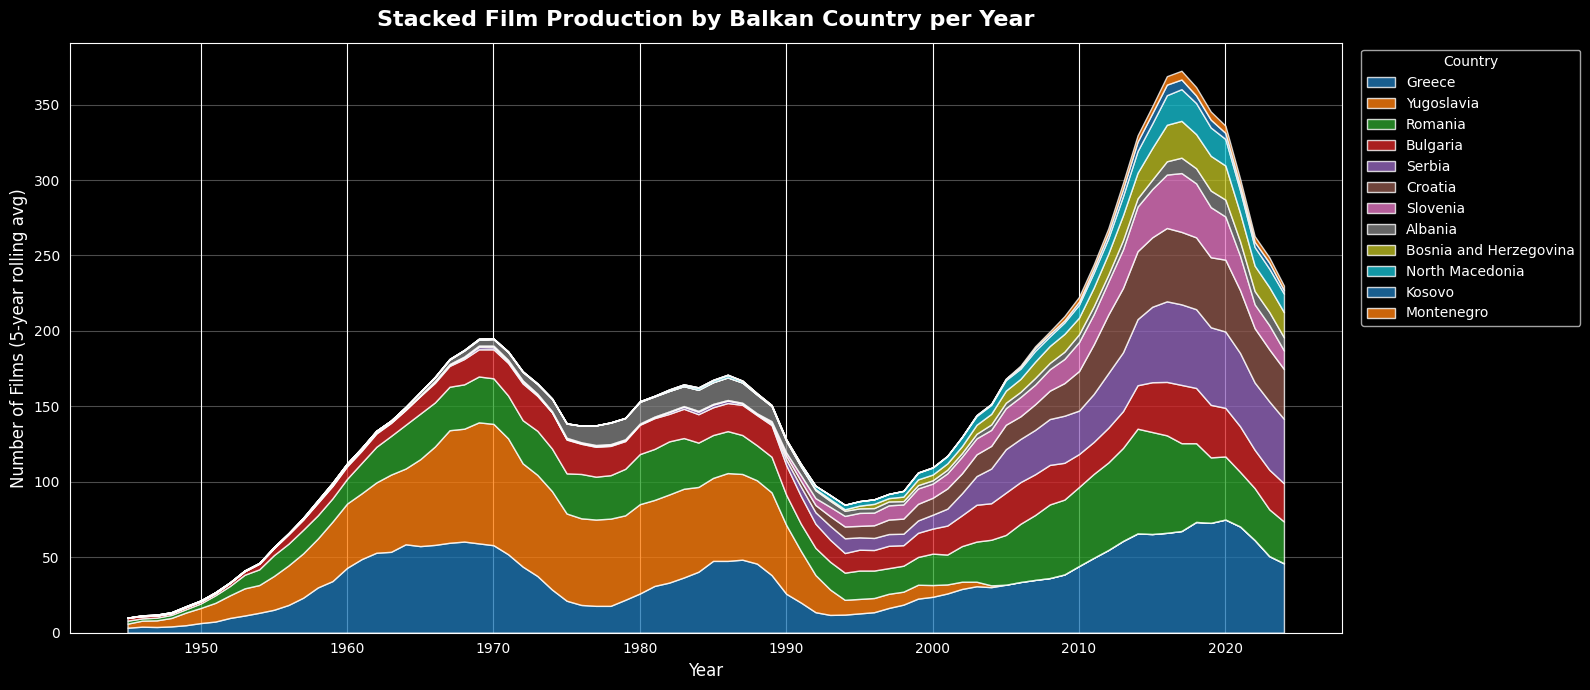

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))

# Use smoothed values for a cleaner stacked area
smoothed = pivot.rolling(5, center=True, min_periods=1).mean()

ax.stackplot(
    smoothed.index,
    [smoothed[c] for c in country_order],
    labels=country_order,
    colors=[color_map[c] for c in country_order],
    alpha=0.8
)

ax.set_title('Stacked Film Production by Balkan Country per Year', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Films (5-year rolling avg)', fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('films_stacked_area.png', dpi=150, bbox_inches='tight')
plt.show()

This graph shows how Balkan filmmaking moved from a state-run era into a total collapse during the 1990s wars, before rebounding into today's record-high production led by many independent nations and cheaper digital technology.


Saving balkan_movies_confirmed.csv to balkan_movies_confirmed (1).csv


/tmp/ipykernel_2047/2972131453.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_overall.values, y=top_10_overall.index, palette='viridis')


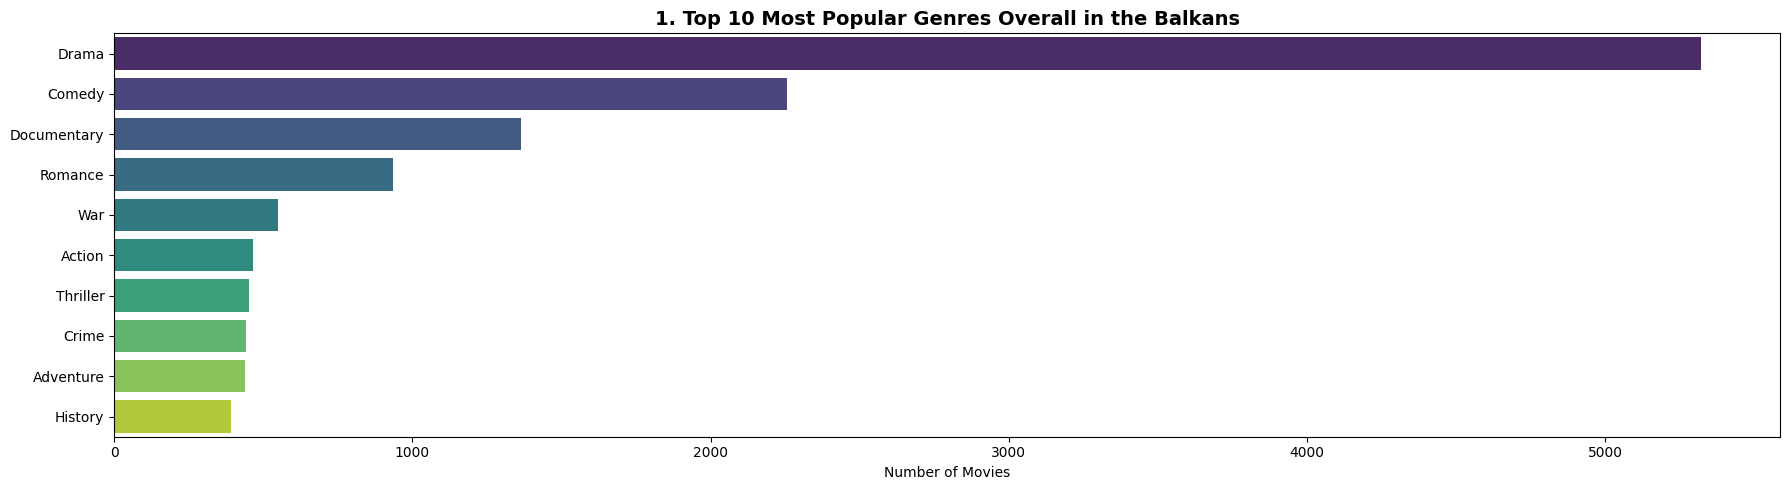

In [ ]:
from google.colab import files
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df = df.dropna(subset=['genres_final', 'country'])

df['country_single'] = df['country'].str.split(',')
df = df.explode('country_single')
df['country_single'] = df['country_single'].str.strip()

balkan_countries = [
    'Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia',
    'Greece', 'Kosovo', 'Montenegro', 'North Macedonia',
    'Romania', 'Serbia', 'Slovenia', 'Yugoslavia', 'Macedonia'
]
df_balkan = df[df['country_single'].isin(balkan_countries)].copy()
df_balkan['country_single'] = df_balkan['country_single'].replace('Macedonia', 'North Macedonia')

df_balkan['genre_single'] = df_balkan['genres_final'].str.split(',')
df_balkan = df_balkan.explode('genre_single')
df_balkan['genre_single'] = df_balkan['genre_single'].str.strip()

top_10_overall = df_balkan['genre_single'].value_counts().head(10)

plt.figure(figsize=(18, 5))
sns.barplot(x=top_10_overall.values, y=top_10_overall.index, palette='viridis')
plt.title('1. Top 10 Most Popular Genres Overall in the Balkans', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('')
plt.tight_layout()
plt.show()

This bar chart shows that Drama and Comedy are by far the most popular genres in the Balkans, reflecting a culture that values storytelling about real-life struggles and social humor. The high ranking of Drama is tied to the region's intense history of war and political change, while Comedy has always been a way for locals to cope with hard times. Documentaries are also common because they are a cheaper way to produce a movie. War and history are low, because those genres are usually referred as drama.

/tmp/ipykernel_2047/2694385711.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, palette='mako')
/tmp/ipykernel_2047/2694385711.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, palette='mako')
/tmp/ipykernel_2047/2694385711.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, palette='mako')
/tmp/ipykernel_2047/2694385711.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is dep

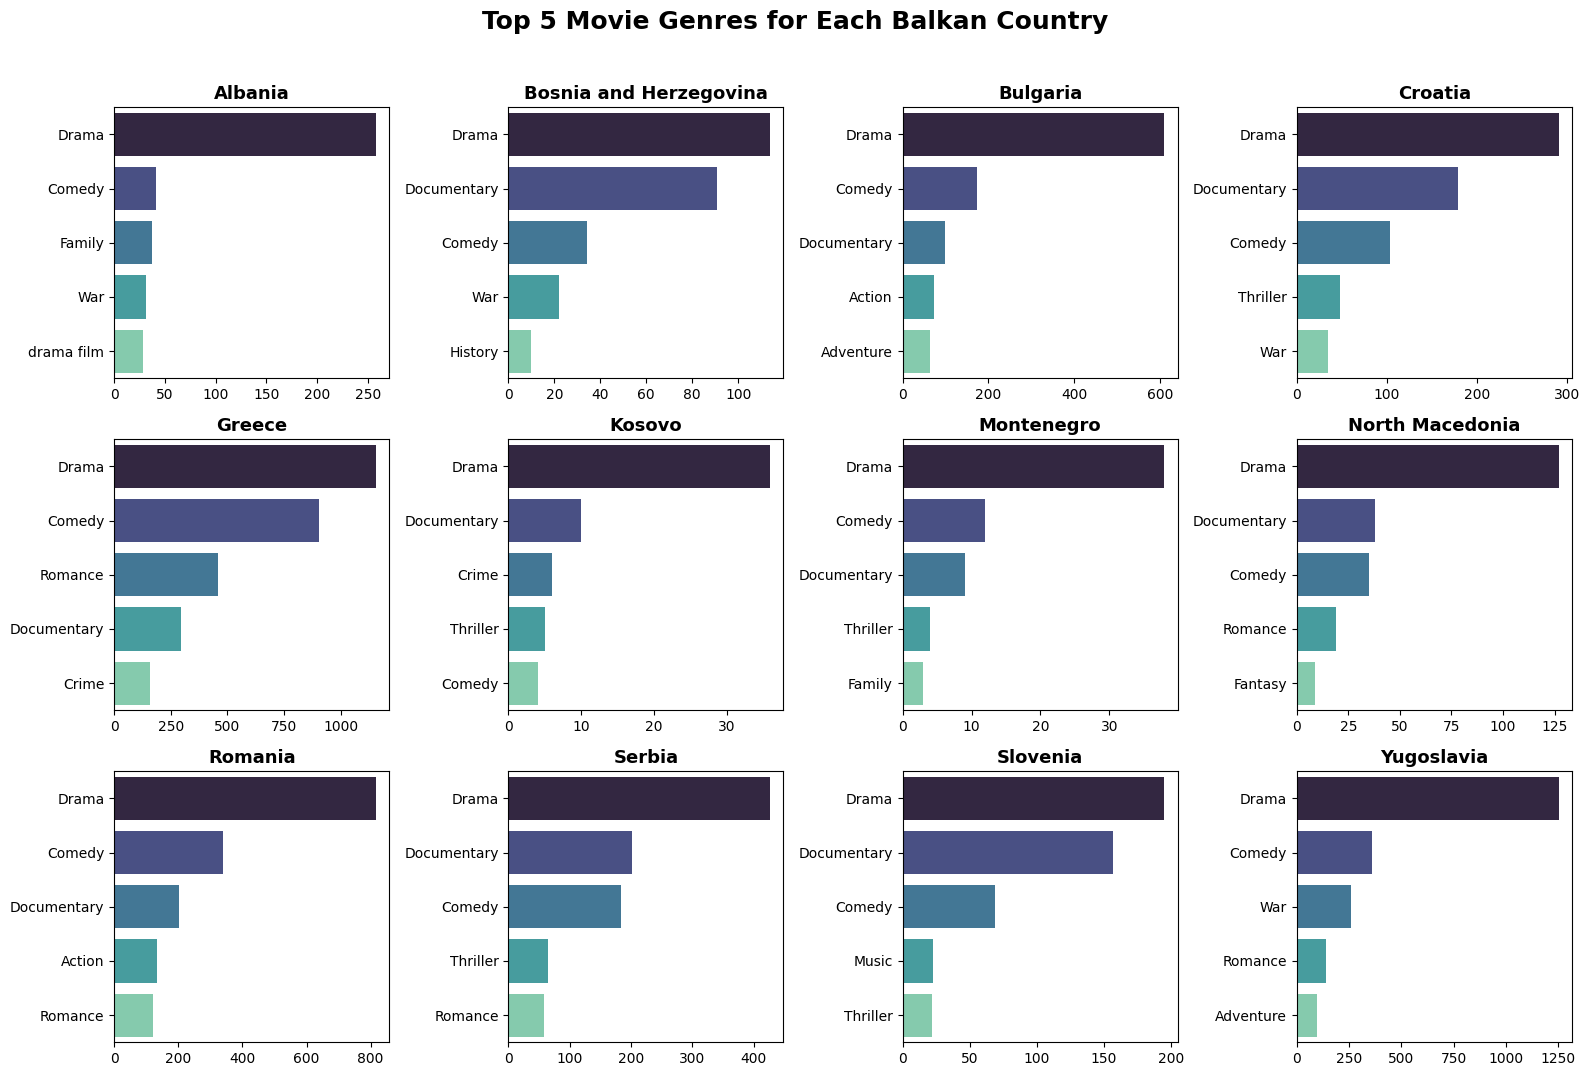

In [ ]:
import math
unique_countries = sorted(df_balkan['country_single'].unique())
cols = 4
rows = math.ceil(len(unique_countries) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows))
axes = axes.flatten()

for i, country in enumerate(unique_countries):
    ax = axes[i]
    country_data = df_balkan[df_balkan['country_single'] == country]
    top_genres = country_data['genre_single'].value_counts().head(5)

    sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, palette='mako')
    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(len(unique_countries), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 5 Movie Genres for Each Balkan Country', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Across the region, Drama is the most common genre because it allows filmmakers to tell serious stories about the Balkans' complex history and personal struggles. Comedy is the second most popular choice, acting as a traditional way for people to find humor even during difficult times. In many countries like Bosnia, Croatia, and Slovenia, Documentaries are very frequent because they are a practical and direct way to record social changes. While most nations share these top interests, specific differences stand out: Greece and Romania produce more Romances, while countries like Albania and Yugoslavia have a higher number of War films, reflecting how much past conflicts still influence their storytelling.

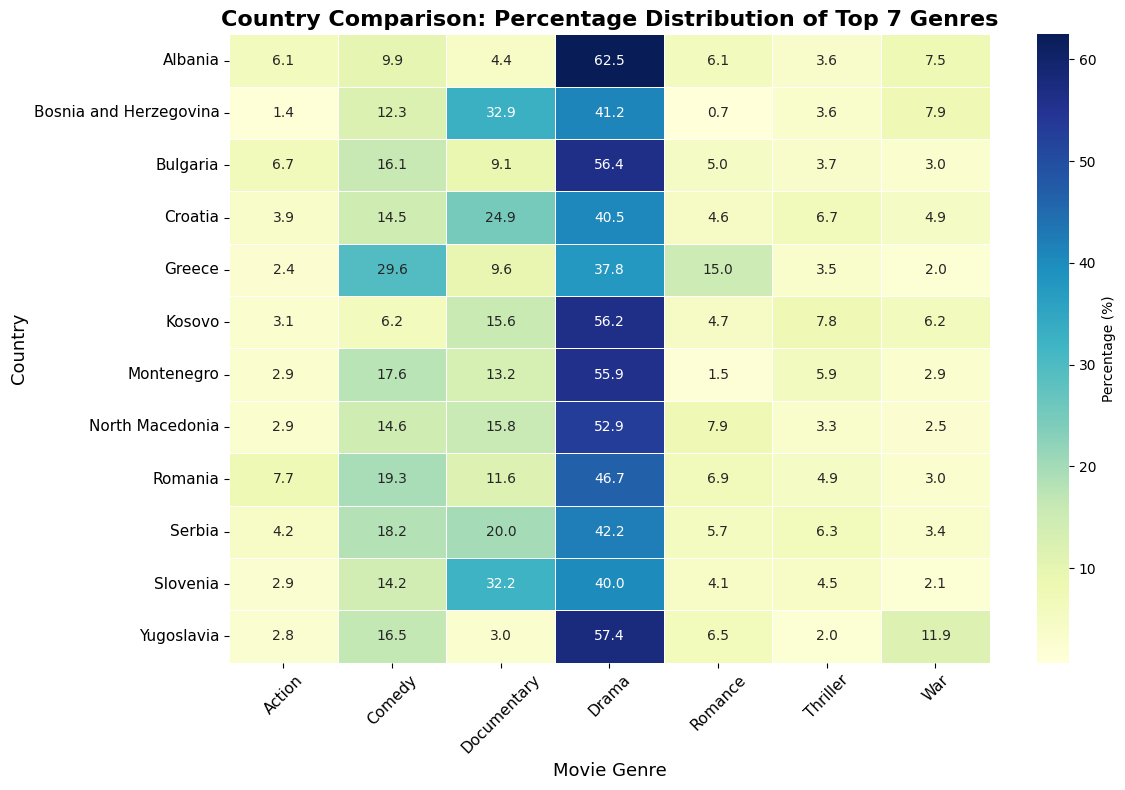

In [ ]:
top_genres = df_balkan['genre_single'].value_counts().head(7).index
df_top = df_balkan[df_balkan['genre_single'].isin(top_genres)]

cross_tab = pd.crosstab(df_top['country_single'], df_top['genre_single'])
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab_pct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage (%)'}, linewidths=.5)
plt.title('Country Comparison: Percentage Distribution of Top 7 Genres', fontsize=16, fontweight='bold')
plt.ylabel('Country', fontsize=13)
plt.xlabel('Movie Genre', fontsize=13)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

This heatmap shows that Drama is the primary genre for every Balkan country. Albania has the highest concentration of Drama at over 62%, while Greece stands out for having the highest percentage of Comedy (nearly 30%) and Romance (15%), showing a more lighthearted commercial history. In contrast, countries like Slovenia and Bosnia dedicate a huge portion of their filmmaking (over 32%) to Documentaries, suggesting a strong focus on real-world reporting and social history.Yugoslavia shows the highest percentage for War films at nearly 12%, which is significantly higher than most modern nations in the group. Overall, while everyone makes Dramas, the data shows that Greece leans toward entertainment, while Bosnia and Slovenia lean toward reality-based storytelling.

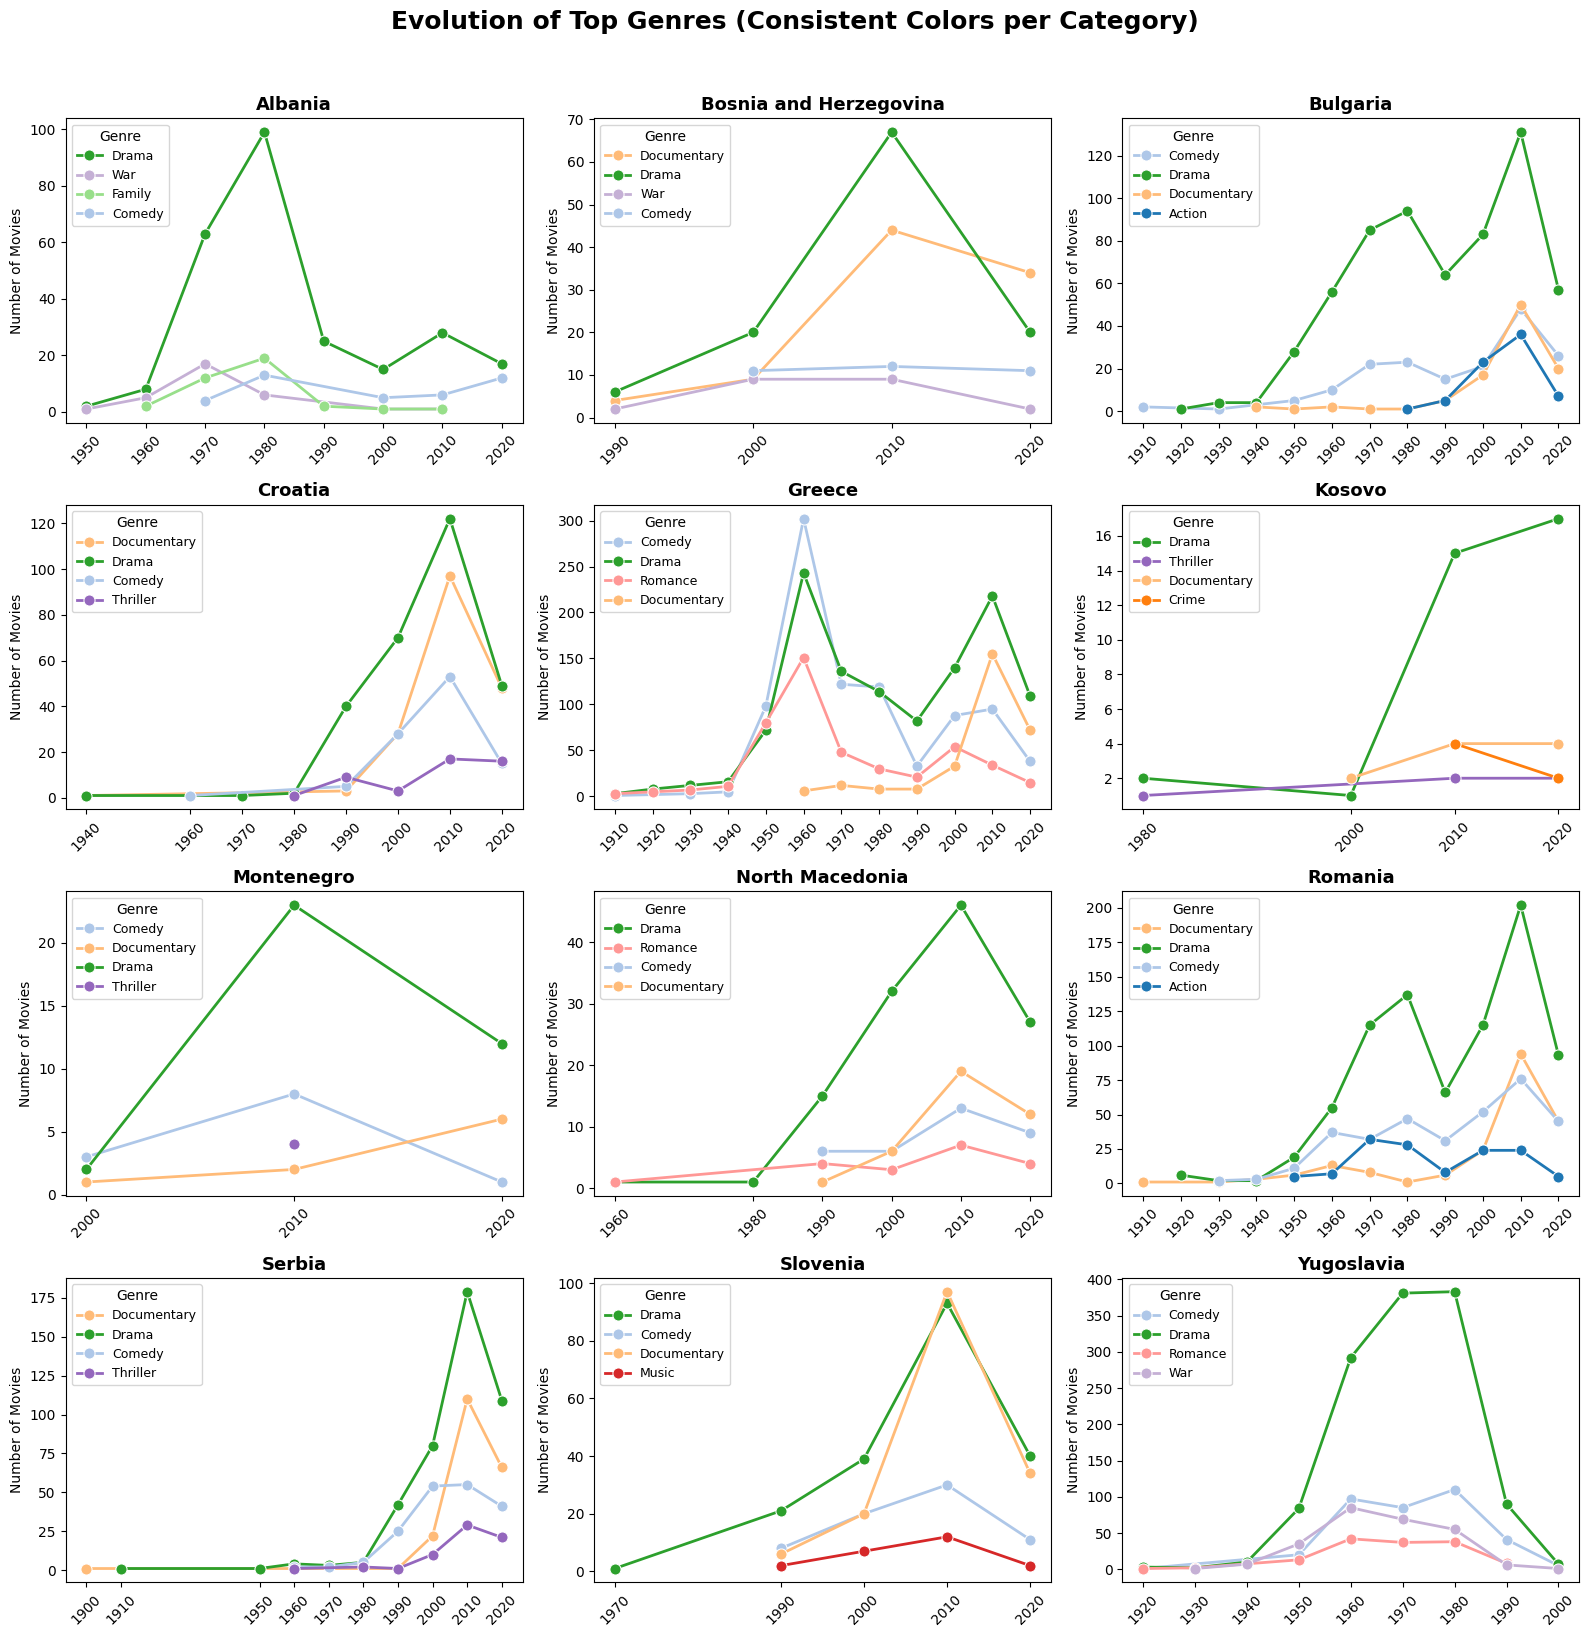

In [ ]:
df_balkan_years = df_balkan.dropna(subset=['year_final']).copy()
df_balkan_years['decade'] = (df_balkan_years['year_final'] // 10 * 10).astype(int)

unique_countries = sorted(df_balkan_years['country_single'].unique())

all_top_genres = set()
for country in unique_countries:
    c_data = df_balkan_years[df_balkan_years['country_single'] == country]
    top_genres = c_data['genre_single'].value_counts().head(4).index
    all_top_genres.update(top_genres)

all_top_genres = sorted(list(all_top_genres))

color_palette = sns.color_palette("tab20", len(all_top_genres))
genre_colors = dict(zip(all_top_genres, color_palette))

cols = 3
rows = math.ceil(len(unique_countries) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, country in enumerate(unique_countries):
    ax = axes[i]
    c_data = df_balkan_years[df_balkan_years['country_single'] == country]

    top_genres = c_data['genre_single'].value_counts().head(4).index
    c_data_top = c_data[c_data['genre_single'].isin(top_genres)]

    trend_data = c_data_top.groupby(['decade', 'genre_single']).size().reset_index(name='count')

    sns.lineplot(data=trend_data, x='decade', y='count', hue='genre_single',
                 palette=genre_colors, marker='o', ax=ax, linewidth=2, markersize=8)

    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Number of Movies')

    decades = sorted(trend_data['decade'].unique())
    if len(decades) > 0:
        ax.set_xticks(decades)
        ax.tick_params(axis='x', rotation=45)

    ax.legend(title='Genre', fontsize=9, loc='upper left')

for j in range(len(unique_countries), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Evolution of Top Genres (Consistent Colors per Category)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

This final set of charts shows how movie tastes have changed over time in each country. While Drama (the green line) has almost always been the most popular choice, the other genres show interesting shifts. In Greece, you can see a huge spike in Comedy (light blue) during the 1960s, which then dropped and was replaced by more serious films later on. In newer countries like Croatia, Serbia, and Slovenia, there is a massive rise in Documentaries (orange) starting around the year 2000, showing a modern trend of using film to record real-life changes. Even though almost every country saw a dip around the year 2020 due to the pandemic, the overall trend shows that Balkan countries are now making a wider variety of movies than ever before. In short, the region has moved from a time when only a few types of movies were made to a modern era where many different genres are growing at the same time.

Saving balkan_movies_master_clean.csv to balkan_movies_master_clean (1).csv


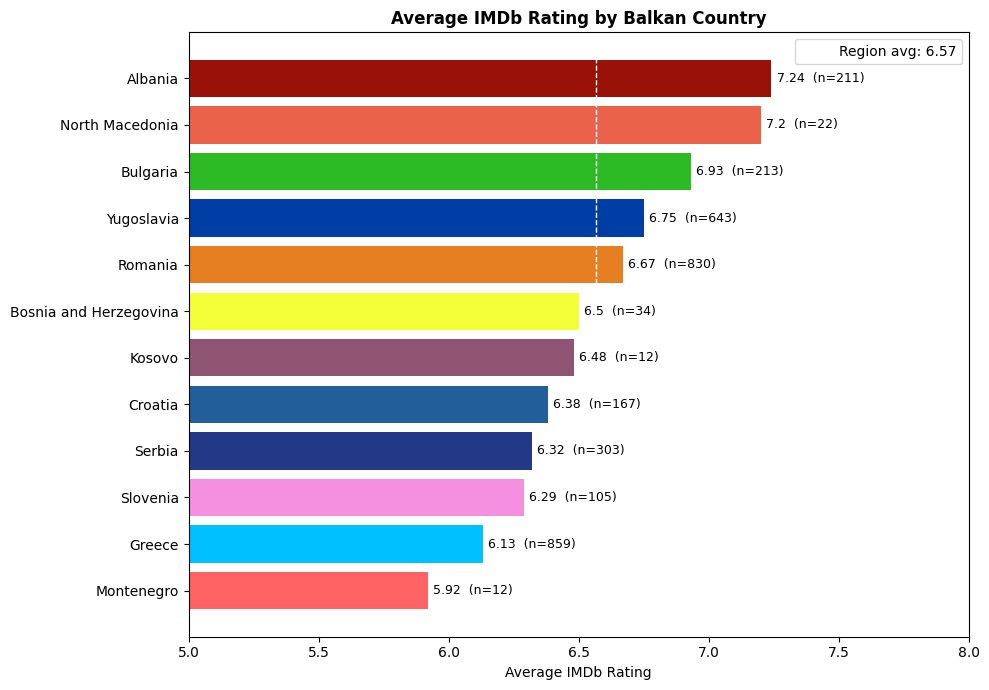

In [22]:

from google.colab import files
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

BALKAN_COUNTRIES = [
    'Romania', 'Greece', 'Yugoslavia', 'Serbia', 'Albania',
    'Bulgaria', 'Croatia', 'Slovenia', 'Bosnia and Herzegovina',
    'North Macedonia', 'Kosovo', 'Montenegro'
]

# We want to have single-country entires (no "France|Romania" for example)
movies = df[df['country'].isin(BALKAN_COUNTRIES)].copy()


imdb_ratings = (
    movies[movies['imdb_rating'].notna()]
    .groupby('country')
    .agg(avg_imdb_rating=('imdb_rating', 'mean'), num_rated_movies=('imdb_rating', 'count'))
    .round(2)
    .sort_values('avg_imdb_rating', ascending=True)
    .reset_index()
)
#gave to each country their color, made like that so i can use it on the other cells
COUNTRY_COLORS = {
    'Albania':                 '#9a1107',
    'Bosnia and Herzegovina':  '#f4ff39',
    'Bulgaria':                '#2dbb25',
    'Croatia':                 '#225f9a',
    'Greece':                  '#00c0ff',
    'Kosovo':                  '#8f5471',
    'Montenegro':              '#ff6363',
    'North Macedonia':         '#eb624b',
    'Romania':                 '#e67e22',
    'Serbia':                  '#213986',
    'Slovenia':                '#f58fe0',
    'Yugoslavia':              '#003DA5',
}

colors = [COUNTRY_COLORS.get(c, 'gray') for c in imdb_ratings['country']]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(imdb_ratings['country'], imdb_ratings['avg_imdb_rating'], color=colors)
ax.axvline(x=imdb_ratings['avg_imdb_rating'].mean(), color='white', linestyle='--', linewidth=1, label=f"Region avg: {imdb_ratings['avg_imdb_rating'].mean():.2f}")
ax.set_xlim(5, 8)

for bar, val, n in zip(bars, imdb_ratings['avg_imdb_rating'], imdb_ratings['num_rated_movies']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val}  (n={n})', va='center', fontsize=9)

ax.set_xlabel('Average IMDb Rating')
ax.set_title('Average IMDb Rating by Balkan Country', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

The Average IMDb Rating chart shows that "quality" is fairly consistent across the region, with most countries scoring between 6.5 and 7.2. However, some of the smaller industries, like Albania and Kosovo, have very high average ratings, but the "n" value shows they only have a few rated movies.

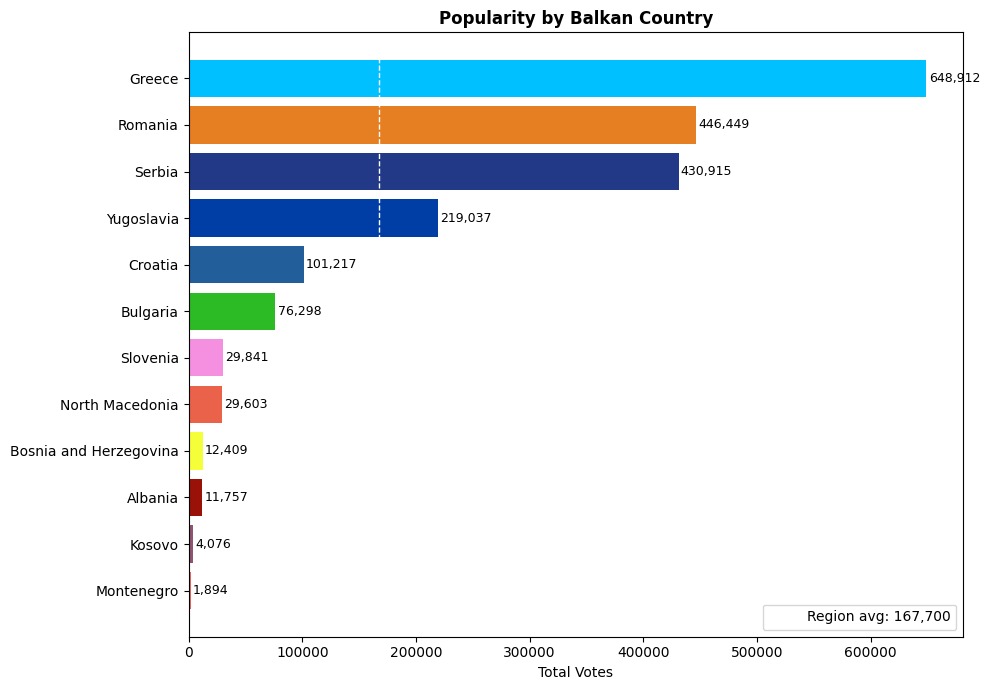

In [23]:
# IMDb votes for popularity by country
popularity = (
    movies[movies['imdb_votes'].notna()]
    .groupby('country')
    .agg(total_votes=('imdb_votes', 'sum'), avg_imdb_votes=('imdb_votes', 'mean'))
    .round(0)
    .sort_values('total_votes', ascending=True)
    .reset_index()
)

colors = [COUNTRY_COLORS.get(c, 'gray') for c in popularity['country']]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(popularity['country'], popularity['total_votes'], color=colors)
ax.axvline(x=popularity['total_votes'].mean(), color='white', linestyle='--', linewidth=1, label=f"Region avg: {int(popularity['total_votes'].mean()):,}")

for bar, val in zip(bars, popularity['total_votes']):
    ax.text(val + 2000, bar.get_y() + bar.get_height()/2, f'{int(val):,}', va='center', fontsize=9)

ax.set_xlabel('Total Votes')
ax.set_title('Popularity by Balkan Country', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

the Popularity chart shows that Greece and Romania are the dominant leaders in global reach. It is true that Greece had a long "Golden Age" of cinema in 80s and the greek weird wave, thanks to Lanthimos success. Also, Romania produces a lot of modern "New Wave" movies the last few years. The countries that are placed last, is because the lack of financial recouurses in order to produce movies.

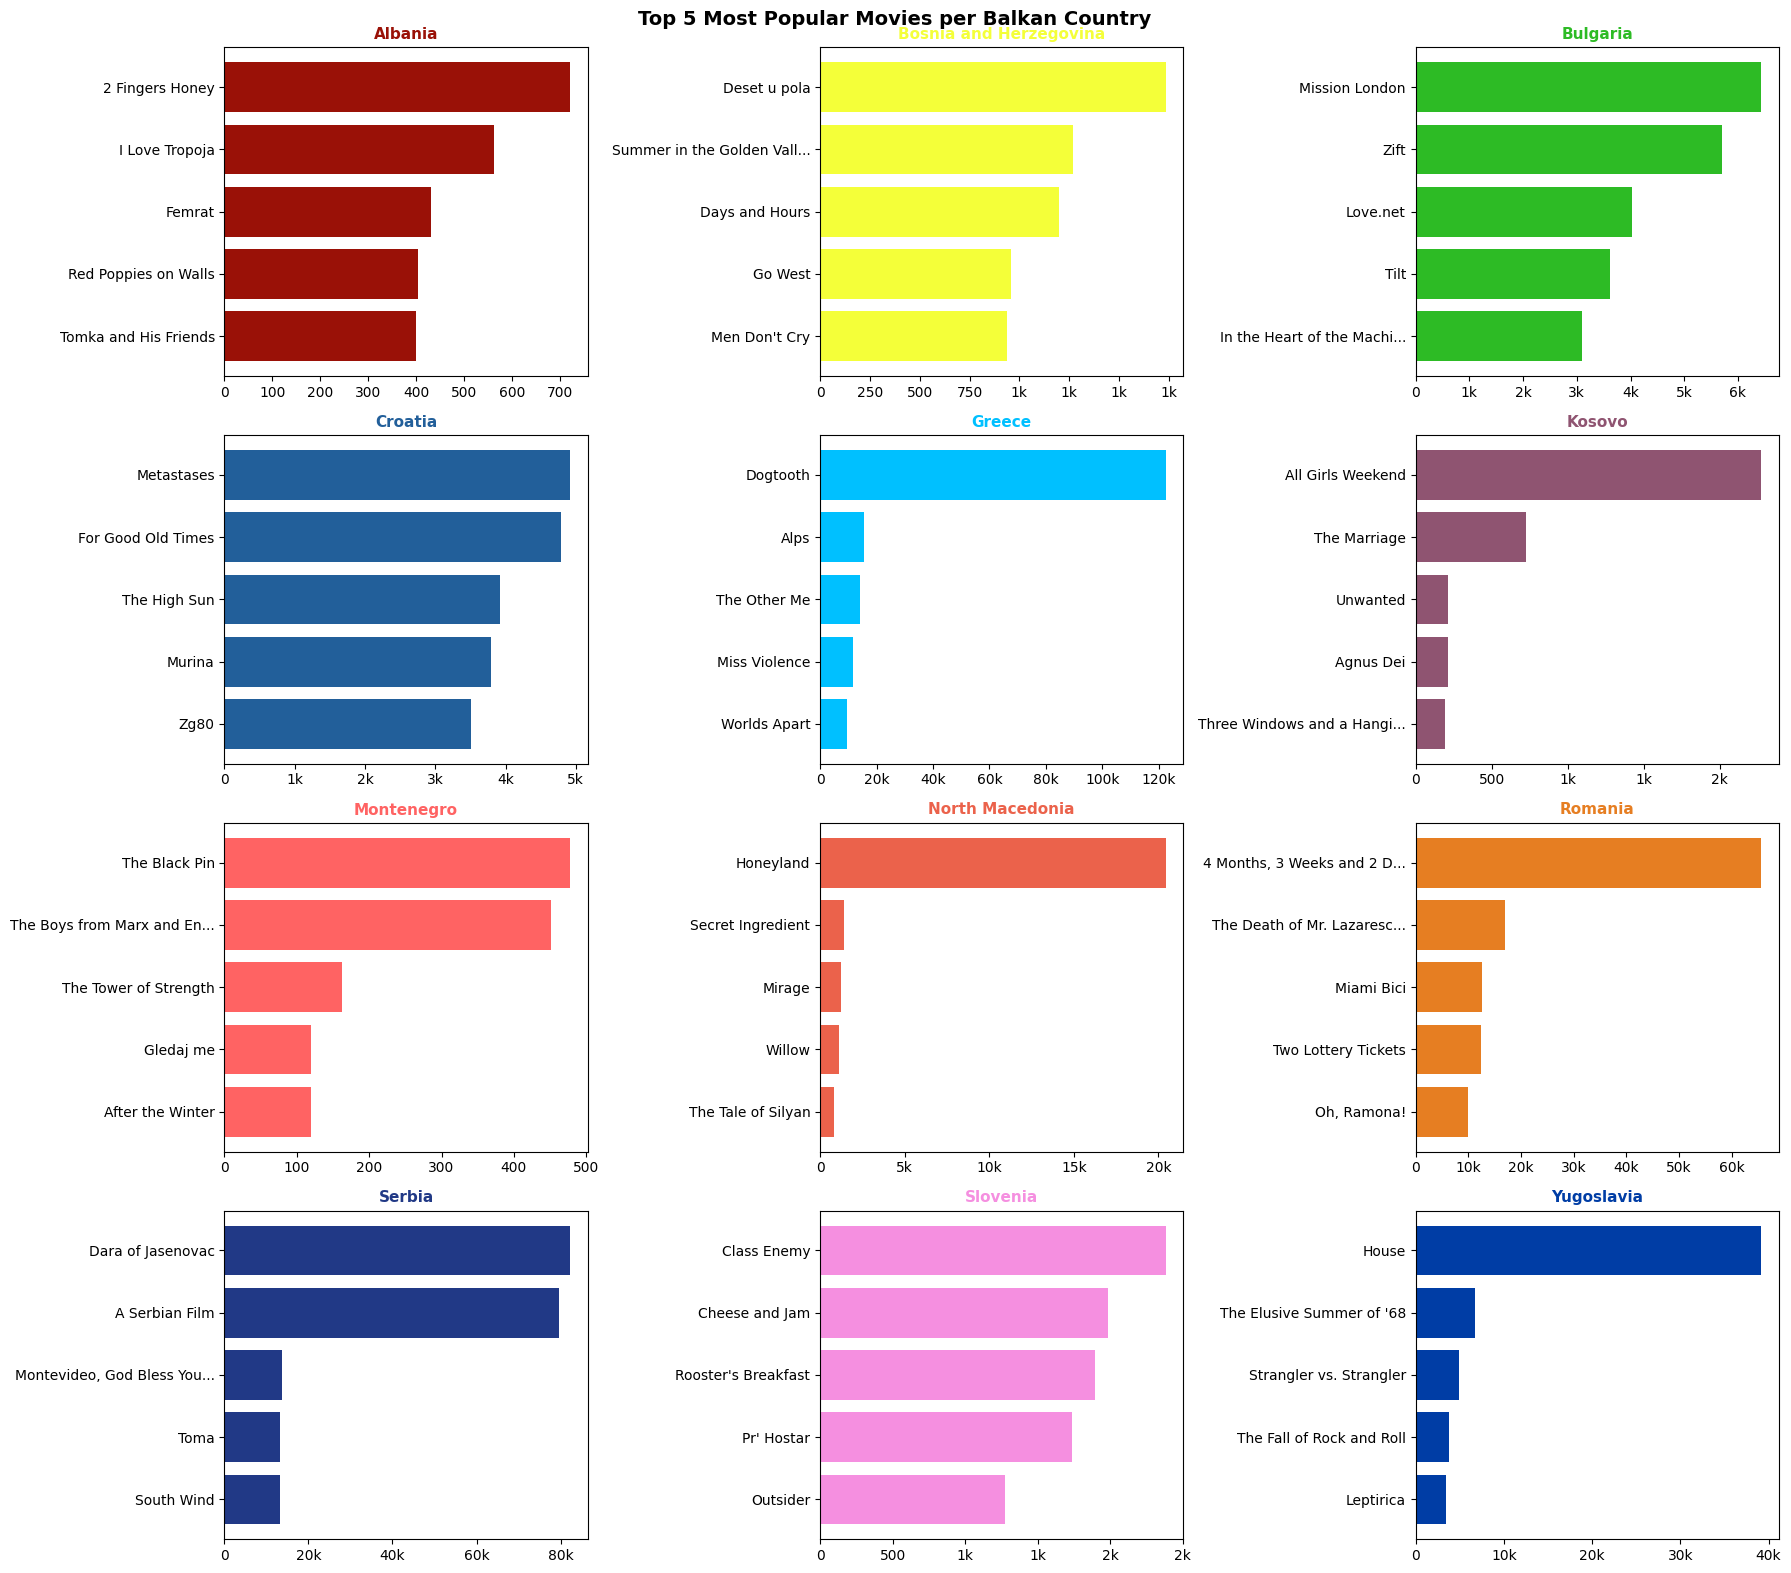

In [25]:
# Top 5 most popular movies per country
top5 = (
    movies[movies['imdb_votes'].notna()]
    .sort_values('imdb_votes', ascending=False)
    .groupby('country')
    .head(5)
    .sort_values(['country', 'imdb_votes'], ascending=[True, False])
)

countries = sorted(top5['country'].unique())
n_cols = 3
n_rows = -(-len(countries) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    data = top5[top5['country'] == country]
    labels = [t[:25] + '...' if len(t) > 25 else t for t in data['title_final']]
    color = COUNTRY_COLORS.get(country, 'gray')
    ax.barh(labels, data['imdb_votes'], color=color)
    ax.set_title(country, fontsize=11, fontweight='bold', color=color)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))
    ax.invert_yaxis()

for j in range(len(countries), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 5 Most Popular Movies per Balkan Country', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

It is obvious the difference in the total number of votes between countries. While top movies in Greece and Romania receive tens of thousands of votes, the leading films in places like Albania and Montenegro have fewer than a thousand. Also the number one movie almost always dominates the rest of the list; for example, "Dogtooth" in Greece and "Honeyland" in North Macedonia have significantly more votes than the second or third-place films in their respective countries.

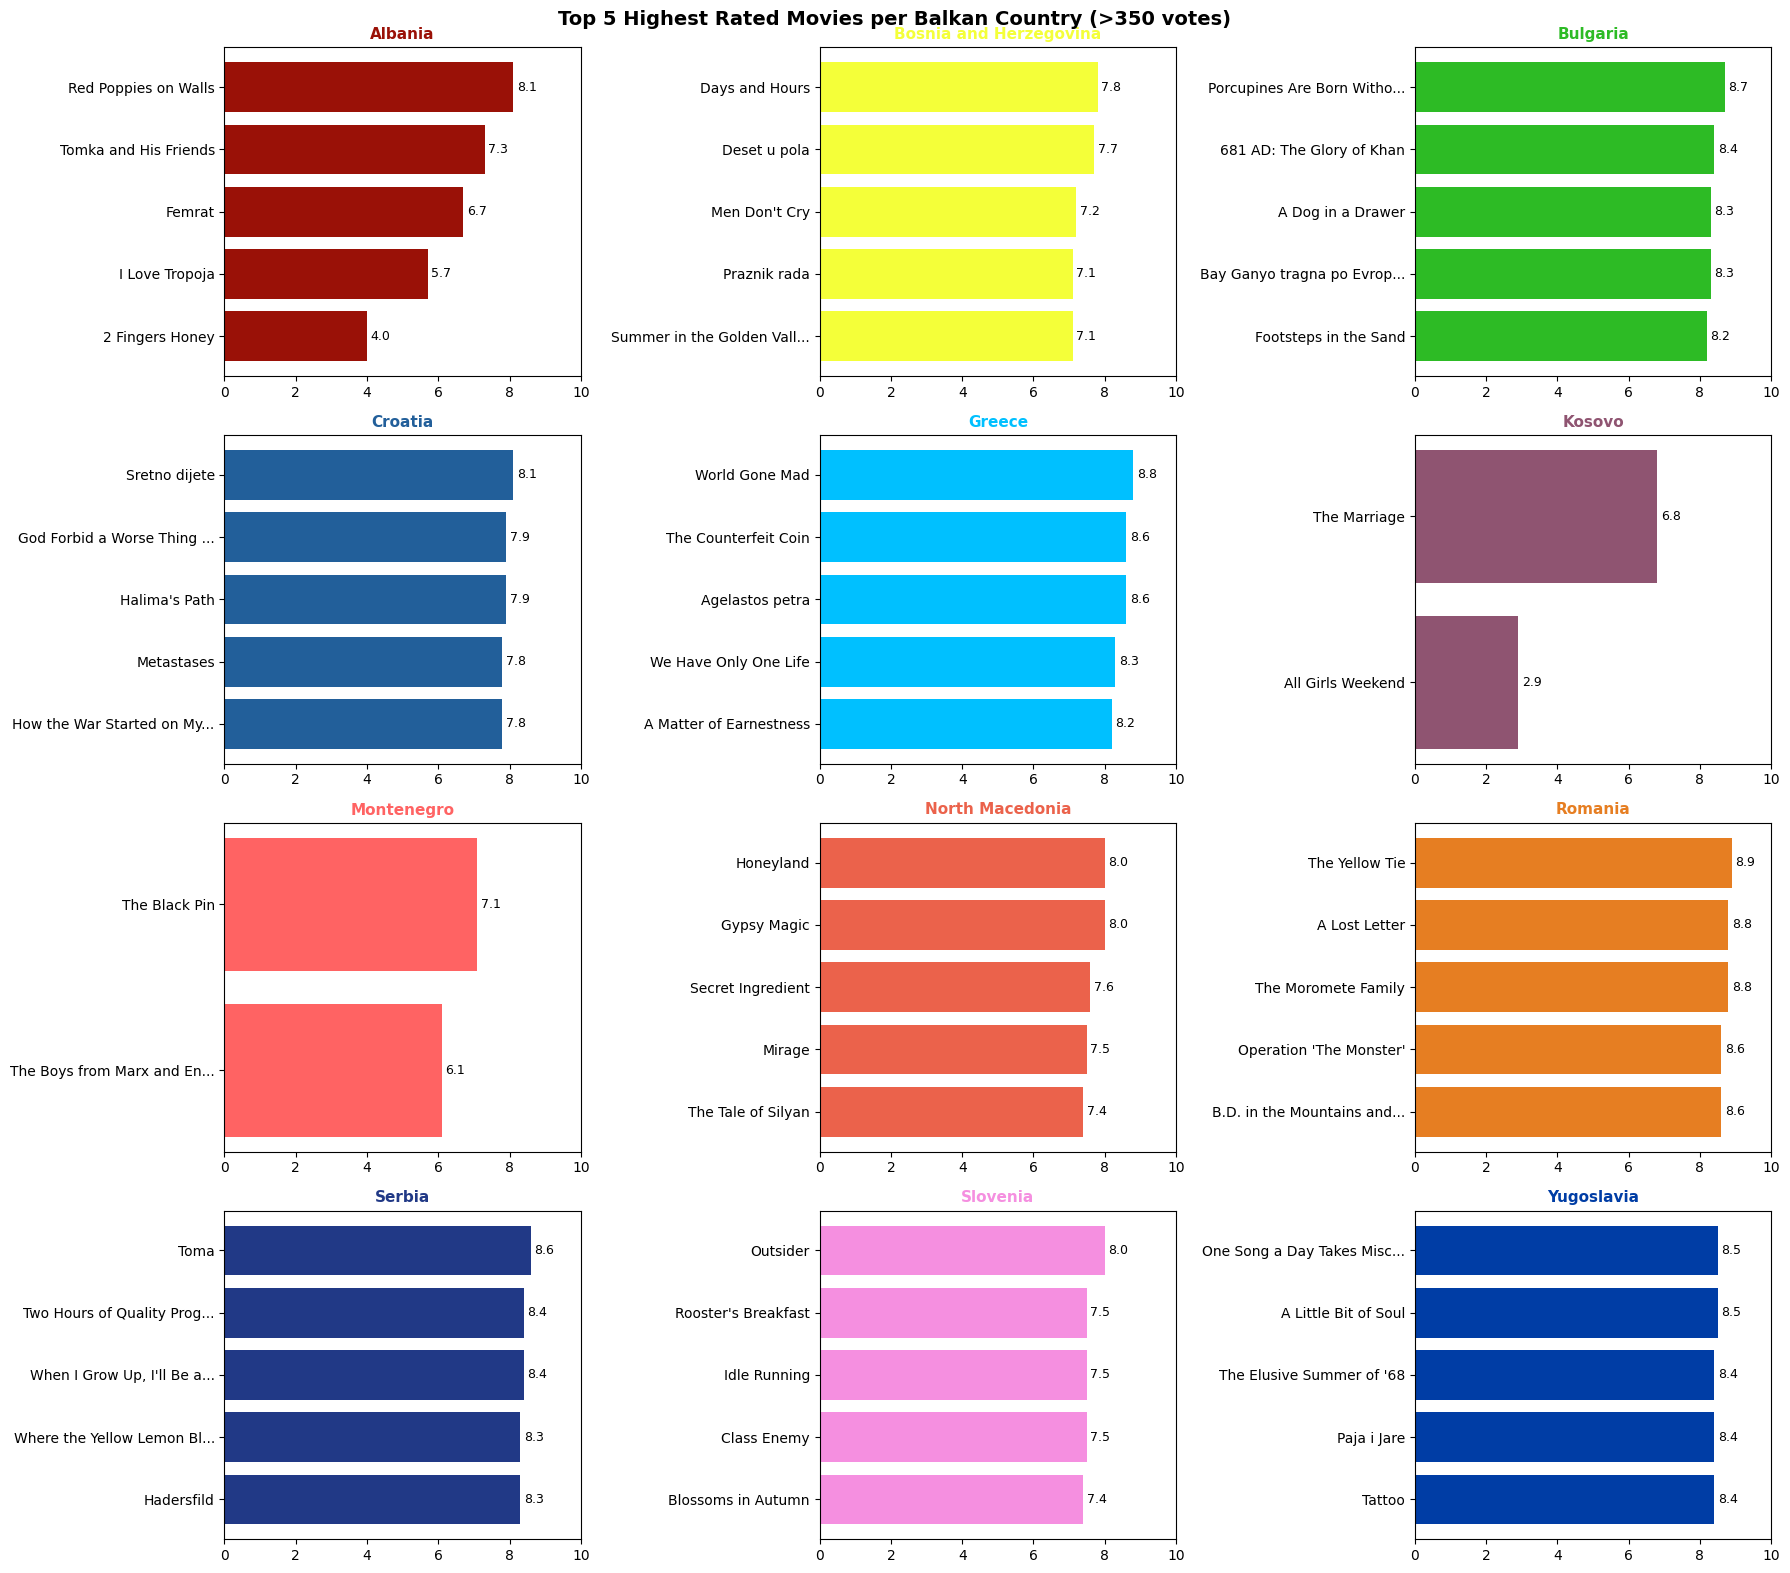

In [27]:
# Top 5 highest rated movies per country with >350 votes
top_rated = (
    movies[(movies['imdb_rating'].notna()) & (movies['imdb_votes'] >= 350)]
    .sort_values('imdb_rating', ascending=False)
    .groupby('country')
    .head(5)
    .sort_values(['country', 'imdb_rating'], ascending=[True, False])
)

countries_r = sorted(top_rated['country'].unique())
n_cols = 3
n_rows = -(-len(countries_r) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, country in enumerate(countries_r):
    ax = axes[i]
    data = top_rated[top_rated['country'] == country]
    labels = [t[:25] + '...' if len(t) > 25 else t for t in data['title_final']]
    color = COUNTRY_COLORS.get(country, 'gray')
    bars = ax.barh(labels, data['imdb_rating'], color=color)
    ax.set_xlim(0, 10)
    ax.set_title(country, fontsize=11, fontweight='bold', color=color)
    ax.invert_yaxis()
    for bar, val in zip(bars, data['imdb_rating']):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=9)

for j in range(len(countries_r), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 5 Highest Rated Movies per Balkan Country (>350 votes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Unlike the previous popularity data, there is very little difference in score between the number one movie and the others on the list for almost every country. Also, it is clear that some countries, like Kosovo and Montenegro, did not have enough movies meeting the 350-vote minimum to even fill out a complete top five list.